In [ ]:
# Cell 0 — CONFIG
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
if sys.platform == "win32":
    project_root = Path(r"F:/MScPROJECT_LOCAL")
else:
    _linux_candidates = [Path("/knuckles_drive"), Path("/workspaces/MScPROJECT_LOCAL")]
    for _candidate in _linux_candidates:
        if _candidate.exists():
            project_root = _candidate
            break
    else:
        sys.path.insert(0, str(Path.cwd() / "src"))  # ensure A_Config is importable before project_root is known
        from A_Config import REPO_ROOT
        project_root = Path(REPO_ROOT)  # robust fallback -- REPO_ROOT is computed from A_Config.py's own location, so it's correct on any machine/mount
print(project_root, project_root.exists())
load_dotenv(project_root / ".env")
case_name = "01_walk"
experiment = "01_walk_sparse_50_02_full"
Question = "Where is the first cat in this video?"

asset_name = f"{case_name}_{experiment}"

sys.path.insert(0, str(project_root / "src")) # added for bufflehead
from A_Config import set_case
set_case(case_name, experiment)


#These neeed work
case_dir     = project_root / "Data" / case_name
source_dir   = case_dir     / "010_source"
query_dir    = case_dir     / "012_Gemini_outputs"
yolo_masks_dir = case_dir   / "015_YOLO" / experiment
#temp delete sub folder
frames_for_cam_poses = case_dir / "020_frames_for_cam_poses" 
frames_for_recon   = case_dir   / "020_frames_for_recon" / experiment 
VGGT_O_output_dir   = case_dir   /"035_VGGT_O_output"/experiment
predictions_path =  case_dir   /  VGGT_O_output_dir /"predictions.npz" 
CUT3R_output_dir    = case_dir   /"035_CUT3R_output" / experiment
ply_dir             =   VGGT_O_output_dir  /"ply"        
print("ply_dir",ply_dir ) 
#temp - need to sort out a unified place? no visualisation is justfor me
reg_dir        = case_dir     / "030_Registrations"
csv_path_GPS = case_dir     / "000_GPS_Data" / "GPS_tags_50_02.csv"
csv_path_pose = reg_dir    /"Registration_reality_scan"/"01_walk_sparse_50_02_full_02" /"01_walk_sparse_50_02_FULL_02.csv"


FRAME_NAME_FMT = "{:04d}.jpg"

#TEMP
#This needs to be filed after user input decides on what to analyse
ppt_template = '03_Version_1'

# video loading
# Auto-find the video in 010_source
videos = list(source_dir.glob("*.mp4"))
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")

#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")

ModuleNotFoundError: No module named 'A_Config'

In [2]:
#LOAD VGGT_O recon for further processing
from Thr3D.F_post_recon_processing import Reconstruction
recon = Reconstruction.load(frames_for_recon, predictions_path, FRAME_NAME_FMT)


In [6]:
#Convert into model space and export into plys
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
ext = recon.preds["extrinsic"][0].clone()

#MAKE PLYS of VGGT__O
#turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
#n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 

_ = recon.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , 
                                        conf_threshold=10, 
                                        R=ext[:,0:3], 
                                        t=ext[:,3], 
                                        s=1)

print(predictions_path)

/workspaces/MScPROJECT_LOCAL/Data/01_walk/035_VGGT_O_output/01_walk_sparse_50_02_full/predictions.npz


In [ ]:
'''#processes spatial information about the recon and the cubject  - for report and generates the data needed to map the subject
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
from Q_subject_analysis import subject_to_metric_and_gps_space
from Thr3D.G_transforms_alignments import  recon_to_recon_transform
R_mw , s_mw, t_mw  = recon_to_recon_transform(recon ,  cam_poses_realworld_dict)



#MAKE PLYS of VGGT__O
#turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
#n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
_ = recon.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" ,conf_threshold = 10, R=R_mw, t=t_mw, s=s_mw)
     '''   


NameError: name 'cam_poses_realworld_dict' is not defined

In [ ]:
# Cell — PLY visualisation
import importlib, sys
sys.path.insert(0, str(project_root / "src"))
import Thr3D.F_cut3r_vis
importlib.reload(Thr3D.F_cut3r_vis)
from Thr3D.F_cut3r_vis import visualise_cut3r

visualisation_dir = case_dir   /  VGGT_O_output_dir
#visualisation_dir = case_dir   /  CUT3R_output_dir
visualise_cut3r(visualisation_dir)

Found 50 PLY files


╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Connection opened (1, 2 total), 218 persistent messages

(viser) Connection closed (0, 1 total)

(viser) Connection opened (0, 1 total), 20 persistent messages

In [ ]:
#BEV from point cloud
#TEST
from Rendering.U_rendering import BEV_render

BEV_render = BEV_render(
        ply_dir,
        "VGGT_O",
        pattern="*.ply",
        width=1920,
        height=1080,
        margin_frac=0.05,#fraction of the fitted extent left as empty border on each side
       
        camera_forward=(0.0, -1.0, 0.0),#looking straight down -Y
        camera_up=(0.0, 0.0, -1.0),#defines which world direction is "up" in the frame (north)
        background_color=(0, 0, 0),
    )




In [ ]:


#BEV projection mapping of subject to a selected view
from P_projection_mapping import projection_mapping_sequence, BEV_tile_render_PM
from Two2D.B_video_processing import available_frames

#Use this to project every frame in the recon
extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
extra_indices = [23]
print(extra_indices)
recon = recon
BEV, new_view, ortho_params = BEV_tile_render_PM (recon, 
                     extra_indices, 
                     masks_dir=None, 
                     splat_radius=1,
                   confidence_threshold=0, 
                   margin_frac=0.05)  


[23]
depth conf torch.Size([50, 384, 688])
x_min -1.151137113571167
Y_min -0.15481271157041193
4.589269161224365 3.9132697997614745
out width 3936
out height 3356
h,W 3356 3936
comp internal canvas torch.Size([13209216, 3])
[23]
tensor(2.7705, device='cuda:0')
tensor(2.2671, device='cuda:0')
tensor(2.6580, device='cuda:0')
tensor(2.8691, device='cuda:0')
JBU output size torch.Size([1080, 1920])
world points extrra torch.Size([2073600, 3])
world points extrra tensor(1.9262, device='cuda:0')
comp output size <built-in method size of Tensor object at 0x7ff03d62b1d0>


In [2]:
#Animate the camera (position + heading frustum) over the BEV_tile_render_PM still.
#n_frames is a directly controllable parameter -- not derived from duration*fps.
from P_trace_overlayer import BEV_trace_overlay
#takes from assets dir
BEV_trace_overlay(
    recon,
    extra_indices,
    new_view,
    ortho_params,
    subject_positions=None,
    n_frames=90,
)


ModuleNotFoundError: No module named 'P_trace_overlayer'

(384, 688)


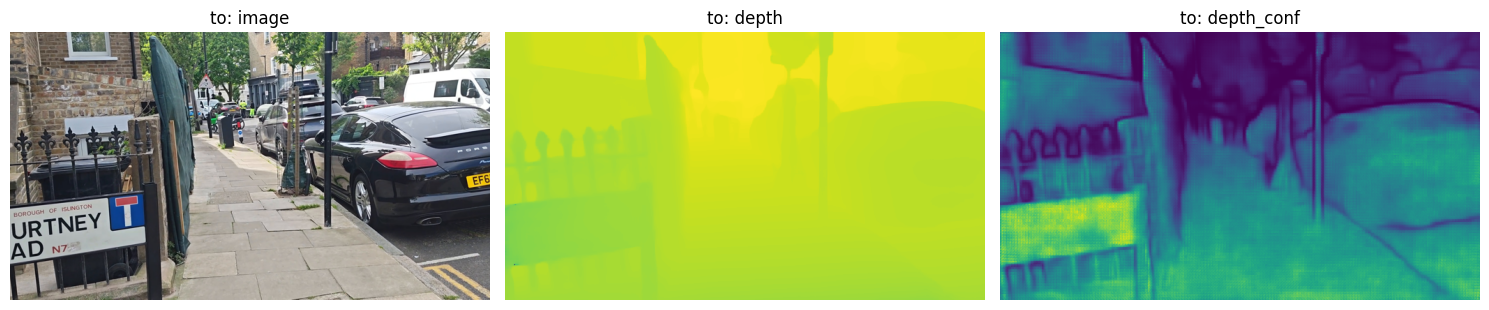

In [ ]:
#QUICK LOOK AT DEPTH MAPS
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

index = 8
img    = recon.preds["images"][index].permute(1, 2, 0).cpu().numpy()
depth    = recon.preds["depth"][index].cpu().numpy()
conf     = recon.preds["depth_conf"][index].cpu().numpy()
print(depth.shape)
# PowerNorm with gamma<1 stretches the low end (near) of the colour ramp and
# compresses the high end (far) -- but unlike a vmax clip, every far pixel still
# gets its own distinct colour, just packed into a smaller share of the ramp.
depth_norm = mcolors.PowerNorm(gamma=0.03, vmin=depth.min(), vmax=depth.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 8))
for ax, im, title in zip(
    axes.ravel(),
    [img, depth, conf],
    ["to: image", "to: depth", "to: depth_conf", "from: image", "from: depth", "from: depth_conf"],
):
    if im is depth:
        ax.imshow(im, cmap="viridis", norm=depth_norm)
    else:
        ax.imshow(im, cmap=None if im.ndim == 3 else "viridis")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


/tmp/ipykernel_59215/3545862441.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


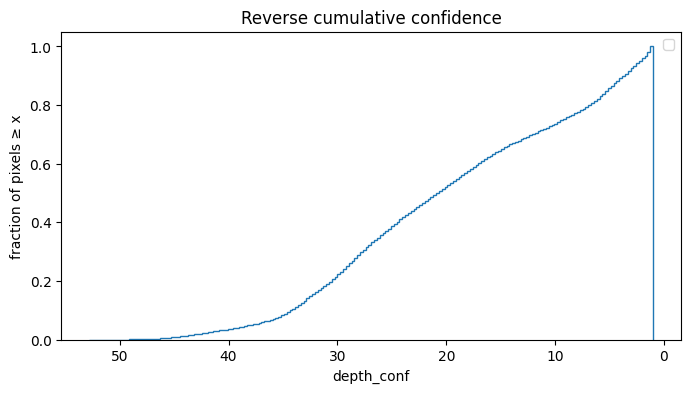

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.hist(conf.ravel(), bins=200, cumulative=-1, density=True, histtype="step")
plt.gca().invert_xaxis()
plt.xlabel("depth_conf")
plt.ylabel("fraction of pixels ≥ x")
#p#lt.#axvline(14, color="tab:red", linestyle="--", label="conf=14")
plt.legend()
plt.title(f"Reverse cumulative confidence")
plt.show()


0.05893509 1.5161508
[ 1.96348392  7.74245834 17.99564362 27.55975914 44.29973698]
(np.float32(0.0154542485), np.float32(3.8485641))


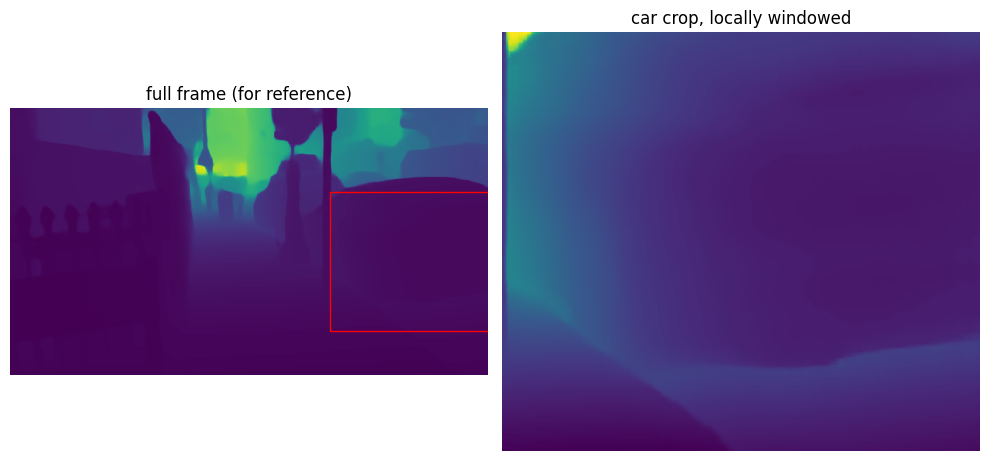

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

index = 8
depth = recon.preds["depth"][index].cpu().numpy()
print(depth.min(), depth.max())
depths = recon.preds["depth"].cpu().numpy()
depth_conf = recon.preds["depth_conf"].cpu().numpy()  # confidence in the depths
print(np.percentile(depth_conf, [5, 25, 50, 75, 95]))
print((depths.min(), depths.max()))
# crop to the car's bounding box in pixel coords (row0:row1, col0:col1) -- adjust to match
row0, row1 = 120, 320
col0, col1 = 460, 800
crop = depth[row0:row1, col0:col1]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(depth, cmap="viridis")
axes[0].add_patch(plt.Rectangle((col0, row0), col1 - col0, row1 - row0, edgecolor="red", facecolor="none"))
axes[0].set_title("full frame (for reference)")
axes[0].axis("off")

axes[1].imshow(crop, cmap="viridis", vmin=crop.min(), vmax=crop.max())
axes[1].set_title("car crop, locally windowed")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [ ]:
print(np.percentile(conf, [5, 25, 50, 75, 95]))
plt.figure(figsize=(8, 4))
plt.hist(depth_conf.ravel(), bins=100, log=True)
plt.xlabel("depth_conf")
plt.ylabel("pixel count (log)")
plt.title(f"Confidence distribution — {conf.shape[0]} frames")
plt.show()

NameError: name 'np' is not defined

0.05893509
1.5161508


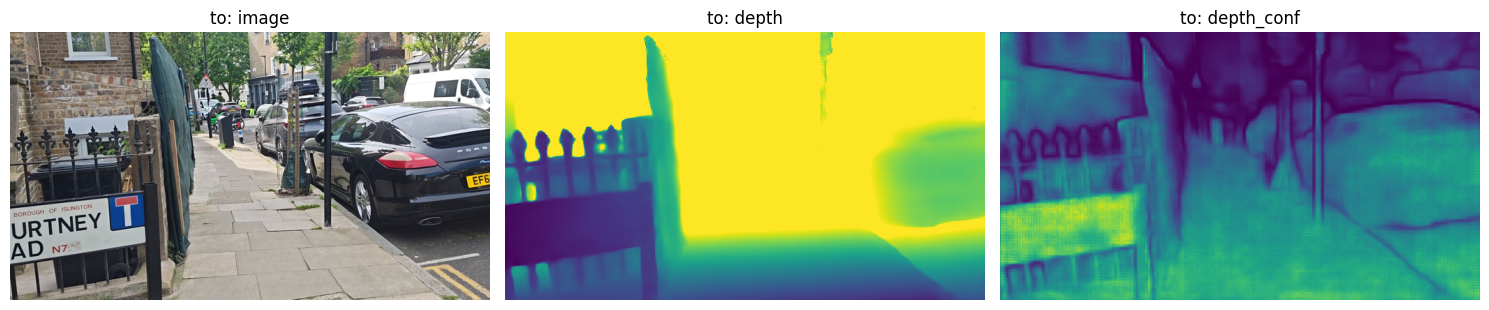

In [ ]:
#QUICK LOOK AT DEPTH MAPS
import matplotlib.pyplot as plt

index = 8
img    = recon.preds["images"][index].permute(1, 2, 0).cpu().numpy()
depth    = recon.preds["depth"][index].cpu().numpy()
conf     = recon.preds["depth_conf"][index].cpu().numpy()

print(depth.min())
print(depth.max())
depth_vmin = depth.min()
depth_vmax = np.percentile(depth, 50)  # tune this percentile to taste

fig, axes = plt.subplots(1, 3, figsize=(15, 8))
for ax, im, title in zip(
    axes.ravel(),
    [img, depth, conf],
    ["to: image", "to: depth", "to: depth_conf", "from: image", "from: depth", "from: depth_conf"],
):
    #ax.imshow(im, cmap=None if im.ndim == 3 else "viridis")
    if im is depth:
        ax.imshow(im, cmap="viridis", vmin=depth_vmin, vmax=depth_vmax)
    else:
        ax.imshow(im, cmap=None if im.ndim == 3 else "viridis")

    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()



In [ ]:
#render projection of 3D points clouds
from Rendering.U_rendering import basic_point_cloud_render
#double way to get vggt and cut3r
if flags["VGGT_O_RECON"] ==True:
    visualisation_dir = case_dir   /  VGGT_O_output_dir 
    model = "VGGT_O"
   

    ply_dir = visualisation_dir / "ply"
    print(ply_dir)
    basic_point_cloud_render(
        ply_dir, model    )
    # report metric name = render name, one row per output asset (path relative to
    


/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03/ply
/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_VGGT_O


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

FULL RES TESTS

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
min depth tensor(0.0155, device='cuda:0')
torch.Size([50, 384, 688, 3])
torch.Size([9795158, 3])
mins, maxes and ranges -0.9337085202336312 0.39871549755334856 1.3324240177869797 -0.07970535354688764 2.267546409461647 2.3472517630085346
scale - original 6000


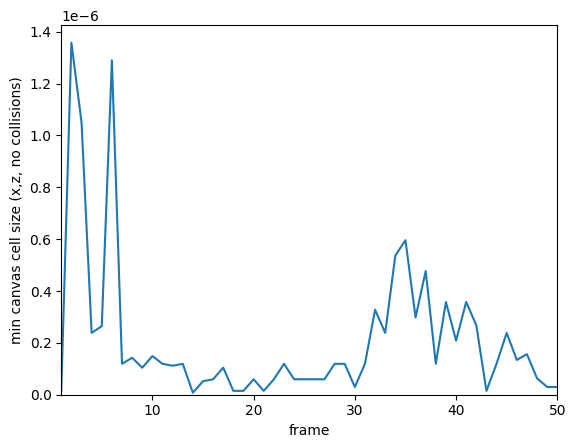

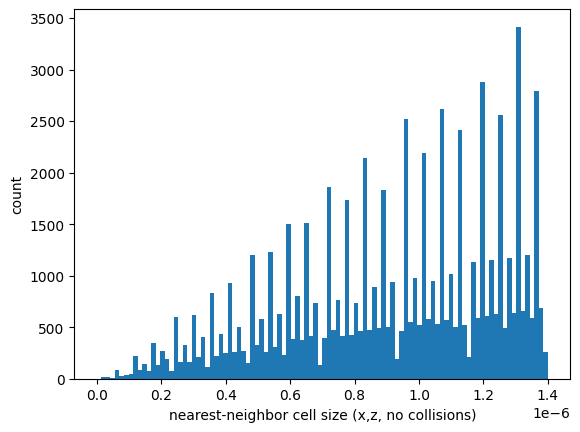

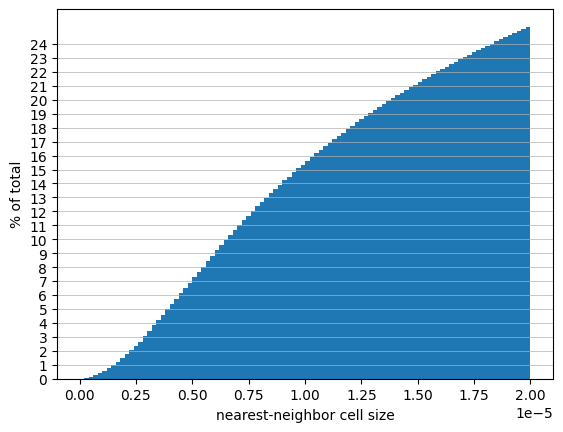

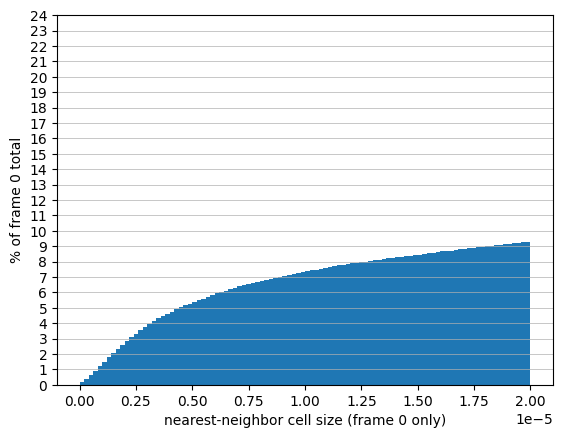

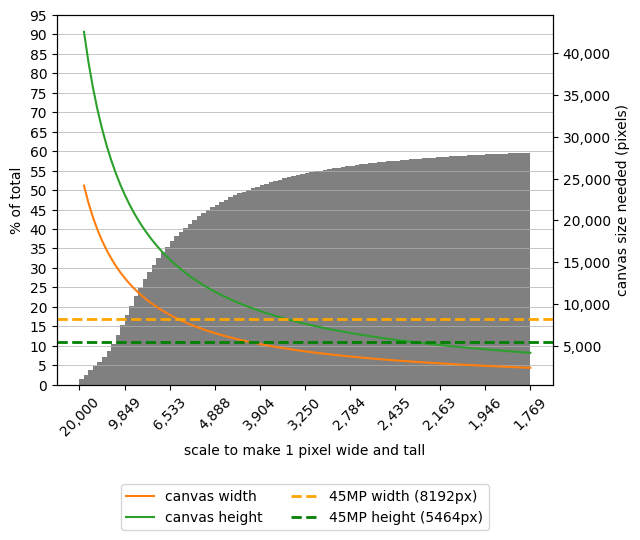

In [8]:
#BEV projection mapping of subject to a selected view
import sys
sys.path.insert(0, "src")
from P_projection_mapping import projection_mapping_sequence, BEV_tile_render_PM

from src.P_projection_mapping import projection_mapping_sequence, BEV_tile_render_PM
from src.B_video_processing import available_frames

#Use this to project every frame in the recon
extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
#extra_indices = [23]
print(extra_indices)
recon = recon
BEV, new_view, ortho_params = BEV_tile_render_PM (recon, 
                     extra_indices, 
                     masks_dir=None, 
                     splat_radius=1,
                   confidence_threshold=8, 
                   margin_frac=0.05,
                   analyse = True,
                   resolution="hires")  


In [ ]:
#BEV from point cloud

from Rendering.U_rendering import BEV_render

BEV_render = BEV_render(
        ply_dir,
        "VGGT_O",
        pattern="*.ply",
        width=7995,
        height=14085,
        margin_frac=0.05,#fraction of the fitted extent left as empty border on each side
        camera_forward=(0.0, -1.0, 0.0),#looking straight down -Y
        camera_up=(0.0, 0.0, -1.0),#defines which world direction is "up" in the frame (north)
        background_color=(0, 0, 0),
    )




(viser) Connection closed (0, 0 total)